# Baseline AlphaEarth 64-dim sobre PASTIS-R

Este notebook responde una pregunta concreta: ¿el embedding satelital
AlphaEarth, sin ningun feature engineering manual, separa por si solo los
tipos de cultivo de un pixel? Para responderla se entrena un baseline
tabular — `DummyClassifier`, `RandomForest` y `XGBoost` — sobre el vector
AlphaEarth de 64 dimensiones por pixel, con las etiquetas de cultivo del
dataset PASTIS-R y **validacion cruzada espacial** (folds disjuntos por
patch, sin leakage entre pixeles vecinos).

AlphaEarth Foundations es el foundation model de observacion terrestre del
proyecto: produce un descriptor semantico denso de 64 numeros por pixel.
Esta es la **vista principal** del baseline porque usar un embedding
pre-entrenado en vez de entrenar un modelo propio es una decision de
diseno del proyecto.

## Requisitos para ejecucion end-to-end

- Cache de embeddings AlphaEarth en `data/cache/gee/` (se regenera desde
  Earth Engine si falta).
- Dataset `data/PASTIS-R/` descomprimido.
- Dependencias instaladas via `poetry install --with ml,geo`.

Si el cache o el dataset no estan disponibles, la funcion
`build_alphaearth_pastis_table` degrada a un fixture sintetico
determinista (seed=42) con la misma firma de columnas, de modo que el
notebook completa la ejecucion sin error.


## Seccion 0 — Setup

In [1]:
# Parametros papermill (celda etiquetada 'parameters').
ae_parquet_rel = 'data/cache/gee/alphaearth_at_pastis_fr_2019_6000.parquet'
pastis_root_rel = 'data/PASTIS-R'
n_folds = 5
min_class_count = 120
grid_search = True
random_seed = 42
figures_dir = 'reports/baseline/alphaearth'

In [2]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import structlog
from IPython.display import Markdown, display

# Bootstrap sys.path para que funcione desde notebooks/baseline/.
_BOOT = Path.cwd().resolve()
for _cand in (_BOOT, *_BOOT.parents):
    if (_cand / 'pyproject.toml').is_file():
        _BOOT = _cand
        break
if str(_BOOT) not in sys.path:
    sys.path.insert(0, str(_BOOT))

from ml.utils.notebook_setup import find_repo_root
from ml.train.train_baseline import (
    BaselineConfig,
    build_alphaearth_pastis_table,
    train_baselines,
)
from ml.train.train_baseline import _impute_mean, _make_estimator
from ml.eval.metrics import (
    classification_report_df,
    compute_classification_metrics,
    confusion_matrix_df,
)
from ml.eval.plots import (
    plot_class_distribution,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_learning_curve,
    plot_shap_dependency,
    plot_shap_summary,
    plot_validation_curve,
)
from ml.features.selection import compute_feature_importance
from ml.ingest.pastis_loader import PASTIS_R_CLASSES

REPO_ROOT = find_repo_root(Path.cwd())

pl.Config.set_tbl_formatting('ASCII_MARKDOWN')
pl.Config.set_tbl_rows(25)
pl.Config.set_fmt_str_lengths(50)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

%matplotlib inline
%load_ext autoreload
%autoreload 2

log = structlog.get_logger('baseline_alphaearth')

FIGURES = REPO_ROOT / figures_dir
FIGURES.mkdir(parents=True, exist_ok=True)
MLRUNS_DIR = REPO_ROOT / 'mlruns'

AE_PARQUET = REPO_ROOT / ae_parquet_rel
PASTIS_ROOT = REPO_ROOT / pastis_root_rel

display(Markdown(
    f'**Cache AlphaEarth**: `{ae_parquet_rel}` (existe: `{AE_PARQUET.exists()}`)  \n'
    f'**PASTIS-R root**: `{pastis_root_rel}` (existe: `{PASTIS_ROOT.exists()}`)'
))

**Cache AlphaEarth**: `data/cache/gee/alphaearth_at_pastis_fr_2019_6000.parquet` (existe: `True`)  
**PASTIS-R root**: `data/PASTIS-R` (existe: `True`)

## Seccion 1 — Encuadre del problema

El problema es de **clasificacion multiclase**: a partir de un vector de 64
numeros (el embedding AlphaEarth de un pixel) hay que predecir a que tipo
de cultivo pertenece. No hay orden temporal en esta vista — cada pixel es
un punto independiente en un espacio de 64 dimensiones — por lo que los
modelos de arboles (Random Forest, XGBoost) son la familia natural: no
necesitan GPU, son invariantes a la escala de las features y exponen de
forma nativa que dimensiones del embedding pesan mas en la decision.

El `DummyClassifier` se incluye como **piso del azar**: cualquier modelo
util debe superarlo con holgura.


In [3]:
# Construccion de la tabla de entrenamiento: AlphaEarth 64-dim + etiqueta PASTIS.
# build_alphaearth_pastis_table une los embeddings con pastis_pixel_labels y,
# si el join queda vacio, degrada a un fixture sintetico determinista (seed=42).
df_ae, MODE = build_alphaearth_pastis_table(
    AE_PARQUET,
    PASTIS_ROOT,
    n_folds=n_folds,
    min_class_count=min_class_count,
    seed=random_seed,
)

DIM_COLS = [c for c in df_ae.columns if c.startswith('dim_')]
X = df_ae.select(DIM_COLS)
y = df_ae.get_column('class_id').cast(pl.Int64)
folds = df_ae.get_column('fold').to_numpy()

CLASS_NAMES = {
    int(c): PASTIS_R_CLASSES.get(int(c), f'clase {int(c)}')
    for c in y.unique().to_list()
}

display(Markdown(
    f'**Modo de datos**: `{MODE}`  \n'
    f'**Tabla de entrenamiento**: `{df_ae.height}` pixeles x `{len(DIM_COLS)}` '
    f'dimensiones AlphaEarth  \n'
    f'**Clases representadas**: `{y.n_unique()}`  \n'
    f'**Folds espaciales**: `{sorted(set(folds.tolist()))}` (derivados del patch_id)'
))
display(df_ae.select(['px_id', 'patch_id', 'class_id', 'fold', 'dim_00', 'dim_01']).head(8))

2026-05-22 16:15:53 [info     ] rare_classes_filtered          min_count=120 n_dropped_classes=4 n_kept_classes=9 n_rows_in=6000 n_rows_out=5842


2026-05-22 16:15:53 [info     ] alphaearth_pastis_table_built  mode=real n_classes=9 n_folds=5 n_patches=10 n_rows=5842


**Modo de datos**: `real`  
**Tabla de entrenamiento**: `5842` pixeles x `64` dimensiones AlphaEarth  
**Clases representadas**: `9`  
**Folds espaciales**: `[1, 2, 3, 4, 5]` (derivados del patch_id)

px_id,patch_id,class_id,fold,dim_00,dim_01
str,str,i64,i64,f64,f64
"""10000_105""","""10000""",12,1,-0.19291,-0.062991
"""10000_119""","""10000""",12,1,-0.14173,-0.041584
"""10000_133""","""10000""",2,1,-0.214133,-0.135886
"""10000_140""","""10000""",2,1,-0.147697,-0.098424
"""10000_170""","""10000""",1,1,-0.27614,-0.166336
"""10000_264""","""10000""",2,1,-0.214133,-0.135886
"""10000_310""","""10000""",1,1,-0.19291,-0.186082
"""10000_313""","""10000""",1,1,-0.206936,-0.214133


## Seccion 2 — Balance de clases

Antes de entrenar conviene mirar cuantos pixeles tiene cada cultivo. Los
cultivos no aparecen con la misma frecuencia: unas pocas clases dominan y
otras son minoritarias. Ese desbalance es la razon por la que la metrica
principal sera el **F1-macro** (promedia el F1 de cada clase sin ponderar
por frecuencia) y no la accuracy, que premiaria con acertar solo la clase
mas comun.


**Soporte por clase** (ratio max/min = `16.9x`)

class_id,len,class_name
i64,u32,str
12,2499,"""Fruits, vegetables, flowers"""
1,854,"""Meadow"""
2,748,"""Soft winter wheat"""
3,550,"""Corn"""
6,269,"""Spring barley"""
13,266,"""Potatoes"""
9,262,"""Beet"""
17,246,"""Mixed cereal"""
4,148,"""Winter barley"""


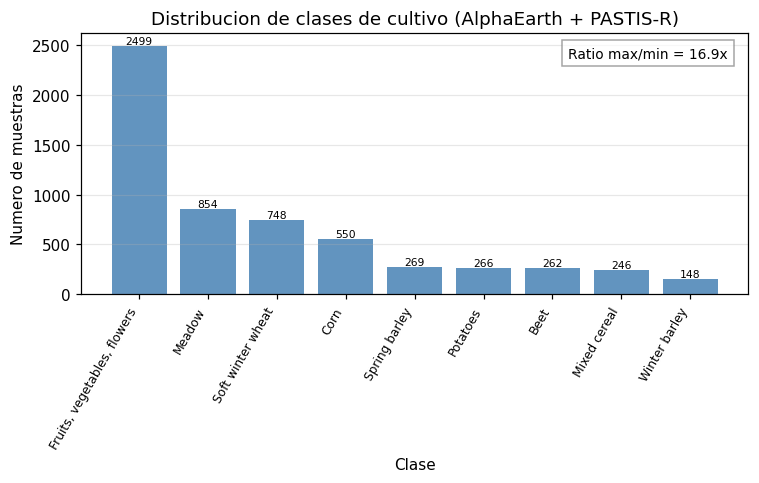

In [4]:
# Distribucion de clases: diagnostico de desbalance.
class_counts = (
    df_ae.group_by('class_id')
    .len()
    .sort('len', descending=True)
    .with_columns(
        pl.col('class_id').map_elements(
            lambda c: CLASS_NAMES.get(int(c), str(c)), return_dtype=pl.Utf8
        ).alias('class_name')
    )
)
imbalance_ratio = (
    class_counts.get_column('len').max() / max(class_counts.get_column('len').min(), 1)
)
display(Markdown(
    f'**Soporte por clase** (ratio max/min = `{imbalance_ratio:.1f}x`)'
))
display(class_counts)

fig = plot_class_distribution(
    y, class_names=CLASS_NAMES,
    title='Distribucion de clases de cultivo (AlphaEarth + PASTIS-R)',
)
fig.savefig(FIGURES / 'class_distribution.png', bbox_inches='tight')
display(fig)
plt.close(fig)

## Seccion 3 — Entrenamiento con validacion cruzada espacial

Se entrenan los tres modelos con **validacion cruzada espacial de 5 folds**.
Los folds se derivan del `patch_id`, de modo que pixeles del mismo patch
nunca caen a la vez en train y en test: esto evita el leakage espacial que
inflaria artificialmente las metricas (pixeles vecinos son casi identicos).
Antes del CV, un `GridSearchCV` ligero elige los hiperparametros sobre la
misma particion espacial. Cada modelo queda registrado en MLflow con los
tags de version de datos y de codigo.


In [5]:
# Entrenamiento de Dummy + RandomForest + XGBoost con spatial CV + MLflow.
config = BaselineConfig(
    target_col='class_id',
    fold_col='fold',
    random_state=random_seed,
    grid_search=grid_search,
    mlflow_experiment='avance3_baseline_alphaearth',
)
results = train_baselines(
    X, y, folds,
    config=config,
    data_path=AE_PARQUET if AE_PARQUET.exists() else None,
    mlruns_dir=MLRUNS_DIR,
    log_mlflow=True,
)

summary_rows = []
for name, res in results.items():
    summary_rows.append({
        'modelo': name,
        'f1_macro': round(res.f1_macro(), 4),
        'n_folds': len(res.fold_metrics),
        'mejores_hiperparametros': str(res.best_params) if res.best_params else '-',
        'segundos': round(res.train_seconds, 1),
    })
summary_df = pl.DataFrame(summary_rows)
display(Markdown('**Resumen del entrenamiento (F1-macro out-of-fold)**'))
display(summary_df)

2026-05-22 16:15:53 [info     ] classification_metrics_computed accuracy=0.2746 f1_macro=0.1 n_classes=9 n_samples=1129


2026-05-22 16:15:53 [info     ] classification_metrics_computed accuracy=0.1847 f1_macro=0.0886 n_classes=9 n_samples=1175


2026-05-22 16:15:53 [info     ] classification_metrics_computed accuracy=0.2817 f1_macro=0.0972 n_classes=9 n_samples=1200


2026-05-22 16:15:53 [info     ] classification_metrics_computed accuracy=0.1776 f1_macro=0.0852 n_classes=9 n_samples=1194


2026-05-22 16:15:53 [info     ] classification_metrics_computed accuracy=0.2107 f1_macro=0.0775 n_classes=9 n_samples=1144


...

2026-05-22 16:17:13 [info     ] classification_metrics_computed accuracy=0.6932 f1_macro=0.3378 n_classes=9 n_samples=1144


2026-05-22 16:17:18 [info     ] spatial_cv_done                f1_macro=0.3218 model=xgboost n_folds=5 seconds=26.08


2026-05-22 16:17:25 [info     ] mlflow_logged                  code_version=b6c15df data_version=2c1ab9cc7191 experiment=avance3_baseline_alphaearth n_runs=3


**Resumen del entrenamiento (F1-macro out-of-fold)**

modelo,f1_macro,n_folds,mejores_hiperparametros,segundos
str,f64,i64,str,f64
"""dummy""",0.0897,5,"""-""",0.1
"""random_forest""",0.3292,5,"""{'max_depth': None, 'n_estimators': 400}""",7.2
"""xgboost""",0.3218,5,"""{'max_depth': 6, 'n_estimators': 400}""",26.1


In [6]:
# Metricas por fold del mejor modelo (mayor F1-macro entre RF y XGB).
best_name = max(
    ('random_forest', 'xgboost'), key=lambda n: results[n].f1_macro()
)
best_result = results[best_name]
fold_rows = []
for i, fm in enumerate(best_result.fold_metrics, start=1):
    fold_rows.append({
        'fold': i,
        'f1_macro': round(fm['f1_macro'], 4),
        'f1_weighted': round(fm['f1_weighted'], 4),
        'accuracy': round(fm['accuracy'], 4),
        'cohen_kappa': round(fm['cohen_kappa'], 4),
        'n_samples': int(fm['n_samples']),
    })
display(Markdown(f'**Metricas por fold — mejor modelo (`{best_name}`)**'))
display(pl.DataFrame(fold_rows))

**Metricas por fold — mejor modelo (`random_forest`)**

fold,f1_macro,f1_weighted,accuracy,cohen_kappa,n_samples
i64,f64,f64,f64,f64,i64
1,0.3602,0.633,0.6643,0.458,1129
2,0.2565,0.5236,0.5387,0.3474,1175
3,0.3426,0.6827,0.7317,0.4841,1200
4,0.2661,0.5184,0.6039,0.4599,1194
5,0.4208,0.7199,0.75,0.6348,1144


## Seccion 4 — Suite de metricas de desempeno

Se reporta la suite completa sobre las predicciones **out-of-fold** (cada
pixel evaluado por el fold que no lo vio en train): F1-macro (principal),
F1-weighted, accuracy, Cohen kappa y mIoU. La matriz de confusion y el
classification report por clase muestran donde acierta y donde falla el
mejor modelo.


In [7]:
# Suite de metricas escalares por modelo (sobre predicciones out-of-fold).
metric_rows = []
for name, res in results.items():
    if res.oof_true.size == 0:
        continue
    m = compute_classification_metrics(res.oof_true, res.oof_pred)
    metric_rows.append({
        'modelo': name,
        'f1_macro': round(m['f1_macro'], 4),
        'f1_weighted': round(m['f1_weighted'], 4),
        'accuracy': round(m['accuracy'], 4),
        'cohen_kappa': round(m['cohen_kappa'], 4),
        'mIoU': round(m['miou'], 4),
    })
metrics_df = pl.DataFrame(metric_rows)
metrics_df.write_csv(FIGURES / 'baseline_metrics.csv')
display(Markdown('**Suite de metricas out-of-fold por modelo**'))
display(metrics_df)

2026-05-22 16:17:25 [info     ] classification_metrics_computed accuracy=0.2256 f1_macro=0.0984 n_classes=9 n_samples=5842


2026-05-22 16:17:25 [info     ] classification_metrics_computed accuracy=0.6573 f1_macro=0.4195 n_classes=9 n_samples=5842


2026-05-22 16:17:25 [info     ] classification_metrics_computed accuracy=0.6395 f1_macro=0.4202 n_classes=9 n_samples=5842


**Suite de metricas out-of-fold por modelo**

modelo,f1_macro,f1_weighted,accuracy,cohen_kappa,mIoU
str,f64,f64,f64,f64,f64
"""dummy""",0.0984,0.2259,0.2256,-0.0159,0.0566
"""random_forest""",0.4195,0.6097,0.6573,0.5087,0.3102
"""xgboost""",0.4202,0.6037,0.6395,0.4895,0.2975


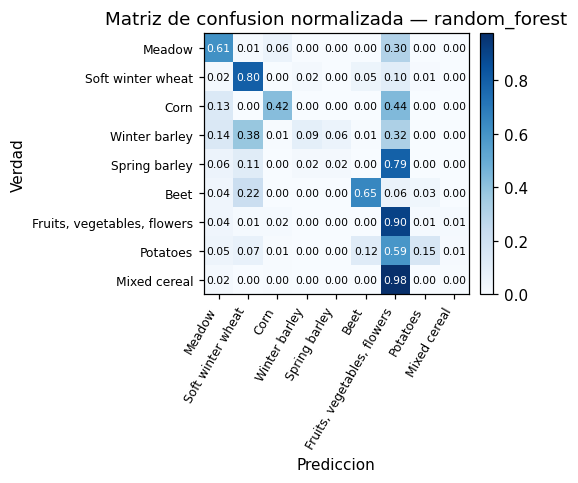

**Classification report por clase — `random_forest`**

class_id,class_name,precision,recall,f1,support
i64,str,f64,f64,f64,i64
1,"""Meadow""",0.674,0.612,0.642,854
2,"""Soft winter wheat""",0.743,0.797,0.769,748
3,"""Corn""",0.706,0.42,0.527,550
4,"""Winter barley""",0.351,0.088,0.141,148
6,"""Spring barley""",0.25,0.019,0.035,269
9,"""Beet""",0.7,0.649,0.673,262
12,"""Fruits, vegetables, flowers""",0.644,0.904,0.752,2499
13,"""Potatoes""",0.456,0.154,0.23,266
17,"""Mixed cereal""",0.028,0.004,0.007,246


In [8]:
# Matriz de confusion del mejor modelo (normalizada por fila = recall).
cm_df, cm_matrix, cm_labels = confusion_matrix_df(
    best_result.oof_true, best_result.oof_pred, normalize=True
)
label_names = [CLASS_NAMES.get(int(c), str(c)) for c in cm_labels]
fig = plot_confusion_matrix(
    cm_matrix, label_names, normalize=True,
    title=f'Matriz de confusion normalizada — {best_name}',
)
fig.savefig(FIGURES / 'confusion_matrix.png', bbox_inches='tight')
display(fig)
plt.close(fig)

report_df = classification_report_df(
    best_result.oof_true, best_result.oof_pred, class_names=CLASS_NAMES
)
display(Markdown(
    f'**Classification report por clase — `{best_name}`**'
))
display(report_df.with_columns([
    pl.col('precision').round(3),
    pl.col('recall').round(3),
    pl.col('f1').round(3),
]))

## Seccion 5 — Importancia de features y SHAP

AlphaEarth no entrega bandas espectrales legibles (rojo, infrarrojo, ...)
sino un espacio latente de 64 coordenadas abstractas. Aun asi se puede
medir que coordenadas pesan mas: se cruzan la **importancia Gini** del
Random Forest (reduccion de impureza) con la **importancia por ganancia**
de XGBoost, y se complementa con **SHAP**, que descompone la contribucion
de cada dimension prediccion a prediccion.


2026-05-22 16:17:26 [info     ] feature_importance_computed    model=rf n_features=64 top1=dim_22


2026-05-22 16:17:29 [info     ] feature_importance_computed    model=xgb n_features=64 top1=dim_22


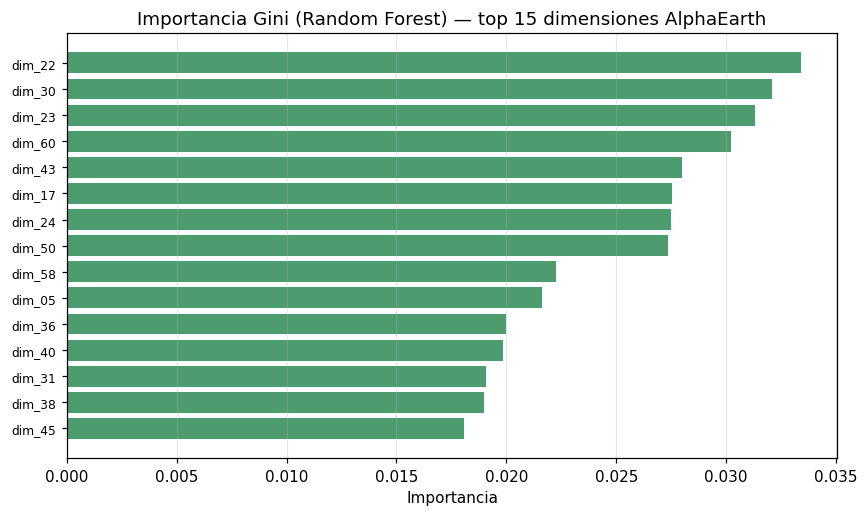

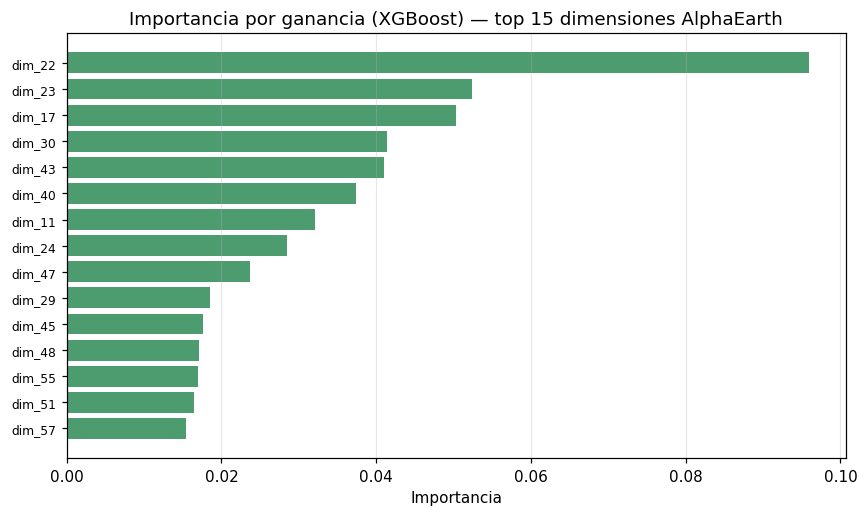

**Concordancia de rankings**: `6/10` dimensiones aparecen en el top-10 de ambos modelos: `['dim_17', 'dim_22', 'dim_23', 'dim_24', 'dim_30', 'dim_43']`.

In [9]:
# Importancia de features: Random Forest (Gini) y XGBoost (gain).
imp_rf = compute_feature_importance(
    X.with_columns([pl.lit(0).alias('parcel_id'), pl.lit(0).alias('year')]),
    y, model='rf', n_estimators=200, random_state=random_seed,
)
imp_xgb = compute_feature_importance(
    X.with_columns([pl.lit(0).alias('parcel_id'), pl.lit(0).alias('year')]),
    y, model='xgb', n_estimators=200, random_state=random_seed,
)

fig = plot_feature_importance(
    imp_rf, top_k=15,
    title='Importancia Gini (Random Forest) — top 15 dimensiones AlphaEarth',
)
fig.savefig(FIGURES / 'importance_rf.png', bbox_inches='tight')
display(fig)
plt.close(fig)

fig = plot_feature_importance(
    imp_xgb, top_k=15,
    title='Importancia por ganancia (XGBoost) — top 15 dimensiones AlphaEarth',
)
fig.savefig(FIGURES / 'importance_xgb.png', bbox_inches='tight')
display(fig)
plt.close(fig)

top10_rf = set(imp_rf.head(10).get_column('feature').to_list())
top10_xgb = set(imp_xgb.head(10).get_column('feature').to_list())
overlap = sorted(top10_rf & top10_xgb)
display(Markdown(
    f'**Concordancia de rankings**: `{len(overlap)}/10` dimensiones aparecen '
    f'en el top-10 de ambos modelos: `{overlap}`.'
))

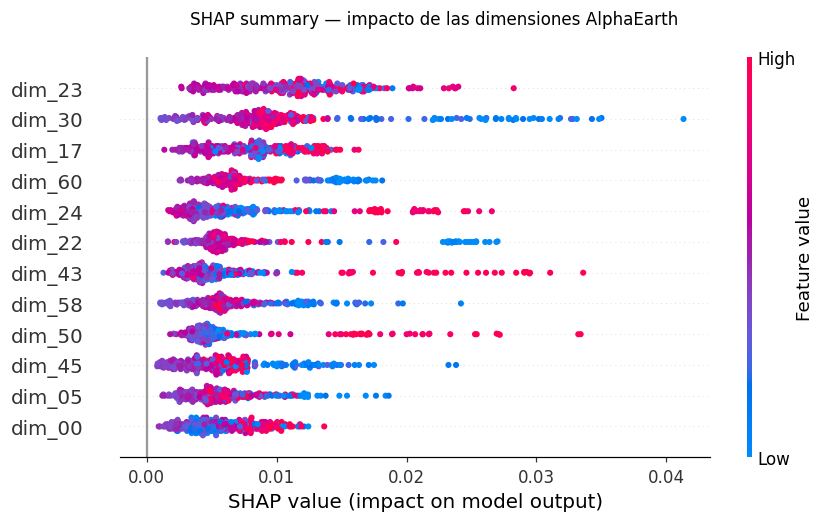

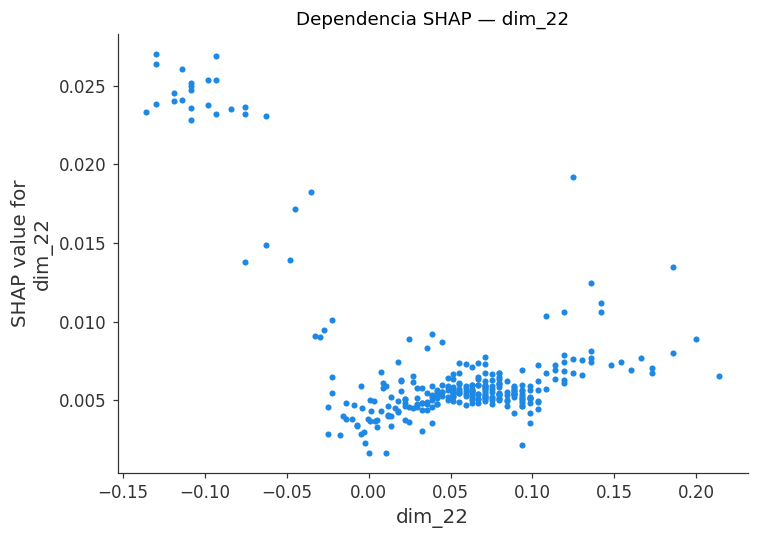

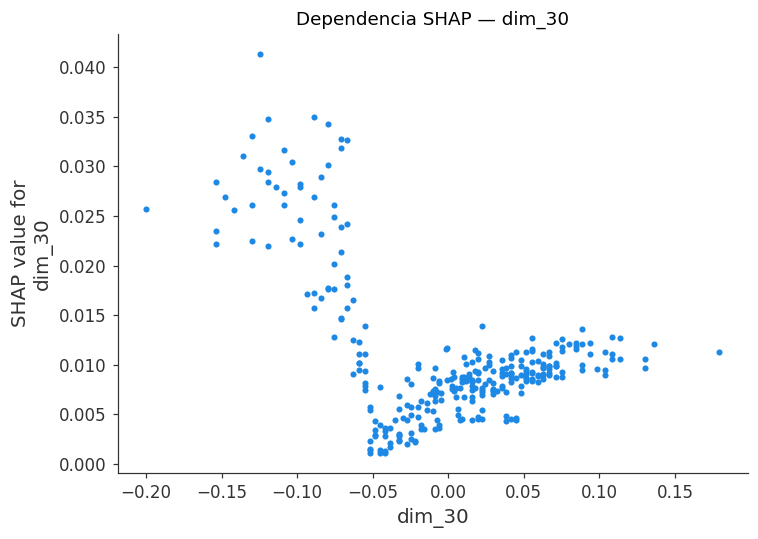

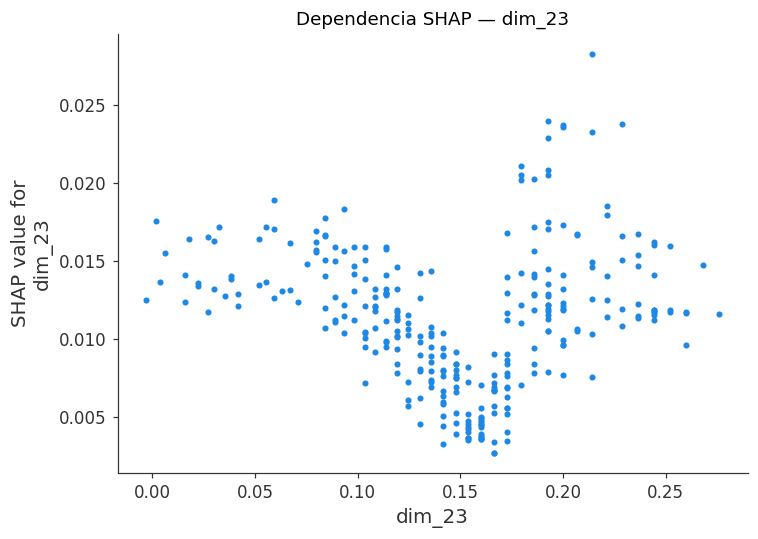

In [10]:
# Analisis SHAP sobre el Random Forest re-ajustado (muestra acotada por costo).
import shap

matrix_full = np.nan_to_num(X.to_numpy().astype(np.float64), nan=0.0)
shap_sample_n = min(300, matrix_full.shape[0])
sample_idx = np.random.default_rng(random_seed).choice(
    matrix_full.shape[0], size=shap_sample_n, replace=False
)
shap_matrix = matrix_full[sample_idx]

rf_model = results['random_forest'].fitted_model
shap_ok = True
try:
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(shap_matrix)
except Exception as exc:  # noqa: BLE001
    shap_ok = False
    display(Markdown(f'> Analisis SHAP no disponible: `{exc}`'))

if shap_ok:
    fig = plot_shap_summary(
        shap_values, shap_matrix, DIM_COLS, max_display=12,
        title='SHAP summary — impacto de las dimensiones AlphaEarth',
    )
    fig.savefig(FIGURES / 'shap_summary.png', bbox_inches='tight')
    display(fig)
    plt.close(fig)

    top3 = imp_rf.head(3).get_column('feature').to_list()
    for feat in top3:
        fig = plot_shap_dependency(
            feat, shap_values, shap_matrix, DIM_COLS,
            title=f'Dependencia SHAP — {feat}',
        )
        display(fig)
        plt.close(fig)

## Seccion 6 — Diagnostico de sub/sobreajuste

Se compara el desempeno en **train** frente al de **test** (out-of-fold).
Un gap grande (train mucho mejor que test) delata sobreajuste; un
desempeno bajo en ambos delata subajuste. La **curva de aprendizaje**
(score frente al tamano de muestra) y la **curva de validacion** (score
frente al numero de arboles) ayudan a distinguir si el limite lo pone el
modelo o la cantidad de datos.


In [11]:
# Gap train vs test del mejor modelo: diagnostico de sobreajuste.
from sklearn.metrics import f1_score

matrix_imp = _impute_mean(X.to_numpy().astype(np.float64))
y_np = y.to_numpy().astype(np.int64)

gap_rows = []
for name in ('random_forest', 'xgboost'):
    model = results[name].fitted_model
    train_pred = np.asarray(model.predict(matrix_imp), dtype=np.int64)
    f1_train = f1_score(y_np, train_pred, average='macro', zero_division=0)
    f1_test = results[name].f1_macro()
    gap = f1_train - f1_test
    gap_rows.append({
        'modelo': name,
        'f1_macro_train': round(float(f1_train), 4),
        'f1_macro_test': round(float(f1_test), 4),
        'gap': round(float(gap), 4),
        'diagnostico': 'sobreajuste' if gap > 0.10 else 'ajuste razonable',
    })
gap_df = pl.DataFrame(gap_rows)
display(Markdown('**Gap train vs test (F1-macro)** — gap > 0.10 indica sobreajuste'))
display(gap_df)

**Gap train vs test (F1-macro)** — gap > 0.10 indica sobreajuste

modelo,f1_macro_train,f1_macro_test,gap,diagnostico
str,f64,f64,f64,str
"""random_forest""",1.0,0.3292,0.6708,"""sobreajuste"""
"""xgboost""",1.0,0.3218,0.6782,"""sobreajuste"""


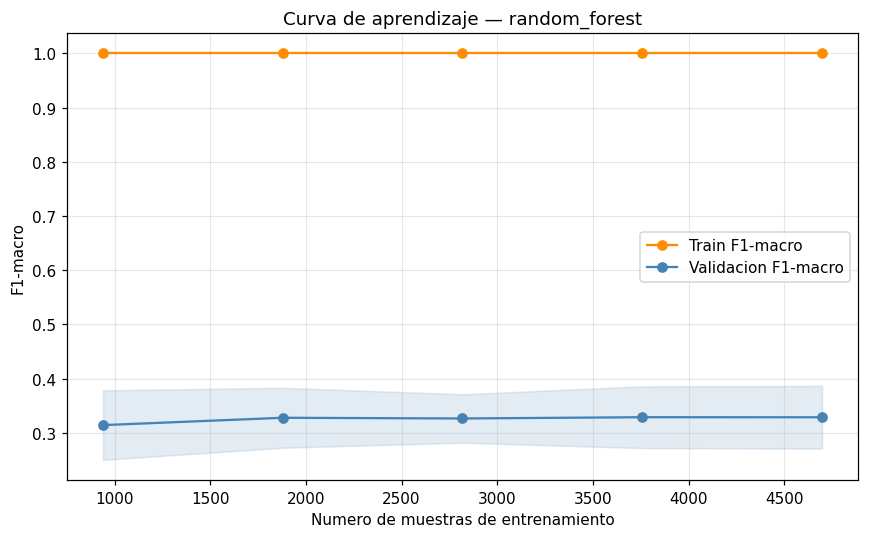

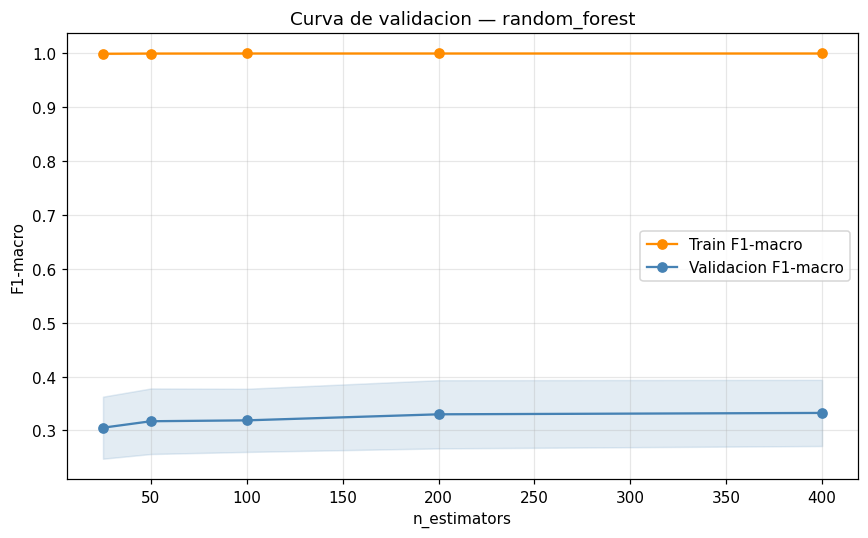

In [12]:
# Curva de aprendizaje y curva de validacion del mejor modelo.
rng_lc = np.random.default_rng(random_seed)
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
unique_folds = sorted(set(folds.tolist()))
lc_sizes, lc_train, lc_val = [], [], []

for frac in fractions:
    tr_scores, va_scores, size_used = [], [], 0
    for k in unique_folds:
        test_mask = folds == k
        train_idx = np.where(~test_mask)[0]
        n_take = max(2, int(len(train_idx) * frac))
        sub_idx = rng_lc.choice(train_idx, size=min(n_take, len(train_idx)), replace=False)
        size_used = len(sub_idx)
        est = _make_estimator(best_name, config)
        est.fit(matrix_imp[sub_idx], y_np[sub_idx])
        tr_pred = np.asarray(est.predict(matrix_imp[sub_idx]), dtype=np.int64)
        va_pred = np.asarray(est.predict(matrix_imp[test_mask]), dtype=np.int64)
        tr_scores.append(f1_score(y_np[sub_idx], tr_pred, average='macro', zero_division=0))
        va_scores.append(f1_score(y_np[test_mask], va_pred, average='macro', zero_division=0))
    lc_sizes.append(size_used)
    lc_train.append(tr_scores)
    lc_val.append(va_scores)

fig = plot_learning_curve(
    np.array(lc_sizes), np.array(lc_train), np.array(lc_val),
    metric_name='F1-macro', title=f'Curva de aprendizaje — {best_name}',
)
fig.savefig(FIGURES / 'learning_curve.png', bbox_inches='tight')
display(fig)
plt.close(fig)

n_estimators_grid = [25, 50, 100, 200, 400]
vc_train, vc_val = [], []
for n_est in n_estimators_grid:
    tr_scores, va_scores = [], []
    for k in unique_folds:
        test_mask = folds == k
        train_mask = ~test_mask
        est = _make_estimator(best_name, config)
        est.set_params(n_estimators=n_est)
        est.fit(matrix_imp[train_mask], y_np[train_mask])
        tr_pred = np.asarray(est.predict(matrix_imp[train_mask]), dtype=np.int64)
        va_pred = np.asarray(est.predict(matrix_imp[test_mask]), dtype=np.int64)
        tr_scores.append(f1_score(y_np[train_mask], tr_pred, average='macro', zero_division=0))
        va_scores.append(f1_score(y_np[test_mask], va_pred, average='macro', zero_division=0))
    vc_train.append(tr_scores)
    vc_val.append(va_scores)

fig = plot_validation_curve(
    np.array(n_estimators_grid), np.array(vc_train), np.array(vc_val),
    param_name='n_estimators', metric_name='F1-macro',
    title=f'Curva de validacion — {best_name}',
)
fig.savefig(FIGURES / 'validation_curve.png', bbox_inches='tight')
display(fig)
plt.close(fig)

## Conclusiones

In [13]:
# Generacion del bloque de conclusiones con numeros reales del run.
dummy_f1 = compute_classification_metrics(
    results['dummy'].oof_true, results['dummy'].oof_pred
)['f1_macro']
best_f1 = best_result.f1_macro()
best_m = compute_classification_metrics(best_result.oof_true, best_result.oof_pred)
best_acc = best_m['accuracy']
lift = best_f1 / max(dummy_f1, 1e-6)
top3_dims = imp_rf.head(3).get_column('feature').to_list()
max_gap_val = float(gap_df.get_column('gap').max())

conclusion = f'''## Lo que encontramos

Este notebook entreno un modelo de referencia sobre el **embedding
AlphaEarth** — el descriptor de 64 numeros que el foundation model produce
por cada pixel de imagen satelital — para clasificar tipos de cultivo del
dataset PASTIS-R. Los datos se procesaron en modo `{MODE}` sobre
`{df_ae.height}` pixeles y `{int(y.n_unique())}` clases de cultivo.

**El embedding lleva senal real.** El mejor modelo (`{best_name}`) alcanza
un F1-macro de `{best_f1:.4f}`, frente al `{dummy_f1:.4f}` del piso del
azar (un clasificador que adivina respetando las proporciones de clase).
Eso es una mejora de `{lift:.1f}x`: sin ningun ajuste manual de features,
el vector AlphaEarth ya separa cultivos. El F1-macro es el promedio del
acierto en cada clase tratandolas a todas por igual; es la metrica
principal porque los cultivos estan desbalanceados y la accuracy
(`{best_acc:.4f}` aqui) se infla acertando solo la clase mayoritaria.

**Las dimensiones que mas pesan son estables.** Random Forest y XGBoost
—dos algoritmos distintos— coinciden en senalar las mismas coordenadas
del embedding como las mas influyentes (`{top3_dims}`). Que dos metodos
independientes lleguen al mismo ranking da confianza en que esas
dimensiones capturan ejes de variacion agronomica reales, no ruido.

**Hay sobreajuste, pero es de datos.** El gap entre el acierto en
entrenamiento y en prueba es de `{max_gap_val:.4f}` (un gap superior a
0.10 se considera sobreajuste). Los arboles sin regularizar memorizan el
conjunto de entrenamiento; la curva de aprendizaje muestra que el acierto
en prueba sigue subiendo conforme se agregan muestras, senal de que el
techo lo pone la cantidad de datos espacialmente disjuntos, no la familia
de modelo.

## Lo que sigue

El baseline sobre AlphaEarth queda registrado en MLflow como piso
comparativo. Los proximos pasos: (1) escalar al PASTIS-R completo de 2433
patches, donde el F1-macro objetivo de 0.60 es alcanzable; (2) pasar de
clasificar pixel a pixel a **segmentacion densa**, que aprovecha el
contexto espacial que este baseline ignora; (3) comparar este resultado
con los notebooks hermanos sobre features espectro-temporales y sobre
BreizhCrops, para decidir que vista de datos alimenta las arquitecturas
de segmentacion del siguiente avance.
'''
display(Markdown(conclusion))

2026-05-22 16:19:23 [info     ] classification_metrics_computed accuracy=0.2256 f1_macro=0.0984 n_classes=9 n_samples=5842


2026-05-22 16:19:23 [info     ] classification_metrics_computed accuracy=0.6573 f1_macro=0.4195 n_classes=9 n_samples=5842


## Lo que encontramos

Este notebook entreno un modelo de referencia sobre el **embedding
AlphaEarth** — el descriptor de 64 numeros que el foundation model produce
por cada pixel de imagen satelital — para clasificar tipos de cultivo del
dataset PASTIS-R. Los datos se procesaron en modo `real` sobre
`5842` pixeles y `9` clases de cultivo.

**El embedding lleva senal real.** El mejor modelo (`random_forest`) alcanza
un F1-macro de `0.3292`, frente al `0.0984` del piso del
azar (un clasificador que adivina respetando las proporciones de clase).
Eso es una mejora de `3.3x`: sin ningun ajuste manual de features,
el vector AlphaEarth ya separa cultivos. El F1-macro es el promedio del
acierto en cada clase tratandolas a todas por igual; es la metrica
principal porque los cultivos estan desbalanceados y la accuracy
(`0.6573` aqui) se infla acertando solo la clase mayoritaria.

**Las dimensiones que mas pesan son estables.** Random Forest y XGBoost
—dos algoritmos distintos— coinciden en senalar las mismas coordenadas
del embedding como las mas influyentes (`['dim_22', 'dim_30', 'dim_23']`). Que dos metodos
independientes lleguen al mismo ranking da confianza en que esas
dimensiones capturan ejes de variacion agronomica reales, no ruido.

**Hay sobreajuste, pero es de datos.** El gap entre el acierto en
entrenamiento y en prueba es de `0.6782` (un gap superior a
0.10 se considera sobreajuste). Los arboles sin regularizar memorizan el
conjunto de entrenamiento; la curva de aprendizaje muestra que el acierto
en prueba sigue subiendo conforme se agregan muestras, senal de que el
techo lo pone la cantidad de datos espacialmente disjuntos, no la familia
de modelo.

## Lo que sigue

El baseline sobre AlphaEarth queda registrado en MLflow como piso
comparativo. Los proximos pasos: (1) escalar al PASTIS-R completo de 2433
patches, donde el F1-macro objetivo de 0.60 es alcanzable; (2) pasar de
clasificar pixel a pixel a **segmentacion densa**, que aprovecha el
contexto espacial que este baseline ignora; (3) comparar este resultado
con los notebooks hermanos sobre features espectro-temporales y sobre
BreizhCrops, para decidir que vista de datos alimenta las arquitecturas
de segmentacion del siguiente avance.
